In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
scaler=StandardScaler()
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
Scaler=MinMaxScaler()

In [2]:
df1 = pd.read_csv('/content/Dengue3.csv')

In [3]:
df1.head()

,Date,affected-people-per-day,affected-Dhaka(Inside City),daily-affected-Outside-Dhaka,affected-Dhaka(Outside City),affected-Mymensingh,affected-chittagong,affected-khulna,affected-Rajhshahi,affected-Rangpur,affected-Barishal,affected-Syllhet
0,1/1/2022,4.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2/1/2022,11.0,7.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,3/1/2022,29.0,4.0,25.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0
3,4/1/2022,4.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5/1/2022,4.0,2.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          1096 non-null   object 
 1   affected-people-per-day       1088 non-null   float64
 2   affected-Dhaka(Inside City)   1088 non-null   float64
 3   daily-affected-Outside-Dhaka  1088 non-null   float64
 4   affected-Dhaka(Outside City)  1086 non-null   float64
 5   affected-Mymensingh           1086 non-null   float64
 6   affected-chittagong           1086 non-null   float64
 7   affected-khulna               1086 non-null   float64
 8   affected-Rajhshahi            1086 non-null   float64
 9   affected-Rangpur              1086 non-null   float64
 10  affected-Barishal             1086 non-null   float64
 11  affected-Syllhet              1086 non-null   float64
dtypes: float64(11), object(1)
memory usage: 102.9+ KB


In [ ]:
df1.isnull().sum()

,0
Date,0
affected-people-per-day,8
affected-Dhaka(Inside City),8
daily-affected-Outside-Dhaka,8
affected-Dhaka(Outside City),10
affected-Mymensingh,10
affected-chittagong,10
affected-khulna,10
affected-Rajhshahi,10
affected-Rangpur,10


In [5]:
df1= df1.ffill().bfill()
df1['affected-Dhaka'] = df1[['affected-Dhaka(Inside City)','affected-Dhaka(Outside City)']].sum(axis=1)

df1

df1.isnull().sum()

,0
Date,0
affected-people-per-day,0
affected-Dhaka(Inside City),0
daily-affected-Outside-Dhaka,0
affected-Dhaka(Outside City),0
affected-Mymensingh,0
affected-chittagong,0
affected-khulna,0
affected-Rajhshahi,0
affected-Rangpur,0


In [6]:
df1.drop(['affected-Dhaka(Inside City)','affected-Dhaka(Outside City)','daily-affected-Outside-Dhaka'], axis=1, inplace=True)
df1

df1.to_csv('Division.csv', index=False)
df1

,Date,affected-people-per-day,affected-Mymensingh,affected-chittagong,affected-khulna,affected-Rajhshahi,affected-Rangpur,affected-Barishal,affected-Syllhet,affected-Dhaka
0,1/1/2022,4.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0
1,2/1/2022,11.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,7.0
2,3/1/2022,29.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,4.0
3,4/1/2022,4.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0
4,5/1/2022,4.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...
1091,27-12-24,53.0,2.0,12.0,2.0,2.0,1.0,0.0,1.0,33.0
1092,28-12-24,104.0,3.0,7.0,2.0,3.0,0.0,13.0,0.0,76.0
1093,29-12-24,148.0,4.0,27.0,20.0,14.0,0.0,14.0,0.0,69.0
1094,30-12-24,114.0,1.0,11.0,9.0,9.0,0.0,15.0,0.0,69.0


In [7]:
df = df1[['Date', 'affected-Dhaka', 'affected-chittagong', 'affected-Mymensingh', 'affected-khulna', 'affected-Rajhshahi', 'affected-Rangpur', 'affected-Barishal', 'affected-Syllhet']].copy()

df.to_csv('Division.csv', index=False)
df

,Date,affected-Dhaka,affected-chittagong,affected-Mymensingh,affected-khulna,affected-Rajhshahi,affected-Rangpur,affected-Barishal,affected-Syllhet
0,1/1/2022,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2/1/2022,7.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,3/1/2022,4.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4/1/2022,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5/1/2022,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1091,27-12-24,33.0,12.0,2.0,2.0,2.0,1.0,0.0,1.0
1092,28-12-24,76.0,7.0,3.0,2.0,3.0,0.0,13.0,0.0
1093,29-12-24,69.0,27.0,4.0,20.0,14.0,0.0,14.0,0.0
1094,30-12-24,69.0,11.0,1.0,9.0,9.0,0.0,15.0,0.0


#Weather impact on dengue cases in Dhaka

*   List item

*   List item
*   List item


*   List item



In [ ]:
df=df1[['Date','affected-Dhaka']]

In [ ]:
df2=pd.read_csv('/content/d_Dhaka.csv')
df2

,Date,R_Dhaka,R_Tangail,R_Faridpur,R_Madaripur,R_Gopalganj,RH_Dhaka,RH_Tangail,RH_Faridpur,RH_Madaripur,...,Tavg_Dhaka,Tavg_Tangail,Tavg_Faridpur,Tavg_Madaripur,Tavg_Gopalganj,S_Dhaka,S_Tangail,S_Faridpur,S_Madaripur,S_Gopalganj
0,1/1/2022,0,0,0,0,0,71,79,78,80,...,20.0,18.6,18.8,18.4,17.6,5.8,7.3,9.0,5.6,7.1
1,2/1/2022,0,0,0,0,0,83,87,88,91,...,18.3,16.6,16.6,16.4,15.3,4.7,3.1,8.7,0.3,1.0
2,3/1/2022,0,0,0,0,0,74,85,78,85,...,19.1,16.8,17.8,17.0,17.4,4.2,7.0,8.7,5.2,6.5
3,4/1/2022,0,0,0,0,0,76,88,81,85,...,18.9,15.6,17.0,17.5,16.9,4.4,4.7,8.2,5.7,7.3
4,5/1/2022,0,0,0,0,0,83,91,89,87,...,18.0,15.0,16.5,16.6,16.4,3.9,2.6,8.6,3.3,6.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,27-12-24,0,0,0,0,0,59,75,72,80,...,21.6,19.1,20.1,19.1,18.9,5.4,6.8,9.1,6.9,6.3
1092,28-12-24,0,0,0,0,0,65,76,73,80,...,21.3,19.4,20.4,19.2,18.9,5.2,6.1,8.8,6.5,7.0
1093,29-12-24,0,0,0,0,0,64,77,71,80,...,21.6,19.8,20.7,19.5,19.5,5.4,6.0,8.2,6.1,6.6
1094,30-12-24,0,0,0,0,0,59,78,76,81,...,22.3,19.5,20.7,19.5,19.9,5.4,5.6,5.4,6.3,4.3


In [ ]:
df2.isnull().sum()

,0
Date,0
R_Dhaka,0
R_Tangail,0
R_Faridpur,0
R_Madaripur,0
R_Gopalganj,0
RH_Dhaka,0
RH_Tangail,0
RH_Faridpur,0
RH_Madaripur,0


#Mean Weather values of all stations in Dhaka

In [ ]:
df['Rainfall']=df2[['R_Dhaka','R_Tangail','R_Faridpur','R_Madaripur','R_Gopalganj']].mean(axis=1)
df['Humidity']= df2[['RH_Dhaka','RH_Tangail','RH_Faridpur','RH_Madaripur','RH_Gopalganj']].mean(axis=1)
df['Temparature']= df2[['Tavg_Dhaka','Tavg_Tangail','Tavg_Faridpur','Tavg_Madaripur','Tavg_Gopalganj']].mean(axis=1)
df['Sunshine'] = df2[['S_Dhaka','S_Tangail','S_Faridpur','S_Madaripur','S_Gopalganj']].mean(axis=1)
df.to_csv('Dhaka.csv', index=False)
df

/tmp/ipykernel_2095/3099888189.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rainfall']=df2[['R_Dhaka','R_Tangail','R_Faridpur','R_Madaripur','R_Gopalganj']].mean(axis=1)
/tmp/ipykernel_2095/3099888189.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Humidity']= df2[['RH_Dhaka','RH_Tangail','RH_Faridpur','RH_Madaripur','RH_Gopalganj']].mean(axis=1)
/tmp/ipykernel_2095/3099888189.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

,Date,affected-Dhaka,Rainfall,Humidity,Temparature,Sunshine
0,1/1/2022,2.0,0.0,77.4,18.68,6.96
1,2/1/2022,7.0,0.0,88.0,16.64,3.56
2,3/1/2022,4.0,0.0,80.4,17.62,6.32
3,4/1/2022,3.0,0.0,82.0,17.18,6.06
4,5/1/2022,2.0,0.0,86.4,16.50,4.96
...,...,...,...,...,...,...
1091,27-12-24,33.0,0.0,72.0,19.76,6.90
1092,28-12-24,76.0,0.0,73.8,19.84,6.72
1093,29-12-24,69.0,0.0,73.8,20.22,6.46
1094,30-12-24,69.0,0.0,74.4,20.38,5.40


In [ ]:
df.isnull().sum()

,0
Date,0
affected-Dhaka,0
Rainfall,0
Humidity,0
Temparature,0
Sunshine,0


[[0.09432265 0.11442756 0.32914709 0.4621027 ]
 [0.08776186 0.10710373 0.33965467 0.46547974]
 [0.09607257 0.10060503 0.31085532 0.49246707]
 [0.08609004 0.10168808 0.32049293 0.49172896]
 [0.0768196  0.09907811 0.35313394 0.47096834]
 [0.08737383 0.09760844 0.34824428 0.46677344]
 [0.07778192 0.12417947 0.29833355 0.49970506]
 [0.08446639 0.10072872 0.33292602 0.48187886]
 [0.08288863 0.09618651 0.33413324 0.48679163]
 [0.08852858 0.11615964 0.34297812 0.45233365]
 [0.09999175 0.10608213 0.30983554 0.48409058]
 [0.08197439 0.09314425 0.32352127 0.5013601 ]
 [0.09312047 0.14437428 0.32051092 0.44199433]
 [0.08932463 0.1085671  0.30730312 0.49480514]
 [0.08078303 0.12067207 0.31943513 0.47910978]
 [0.08441469 0.11369917 0.31841837 0.48346776]
 [0.07343787 0.10272281 0.33360027 0.49023906]
 [0.08604792 0.09783948 0.32200049 0.49411211]
 [0.08912339 0.09507067 0.32290206 0.49290388]
 [0.08607461 0.11071848 0.29190042 0.51130649]
 [0.08315424 0.11020541 0.30105733 0.50558301]
 [0.09019486 

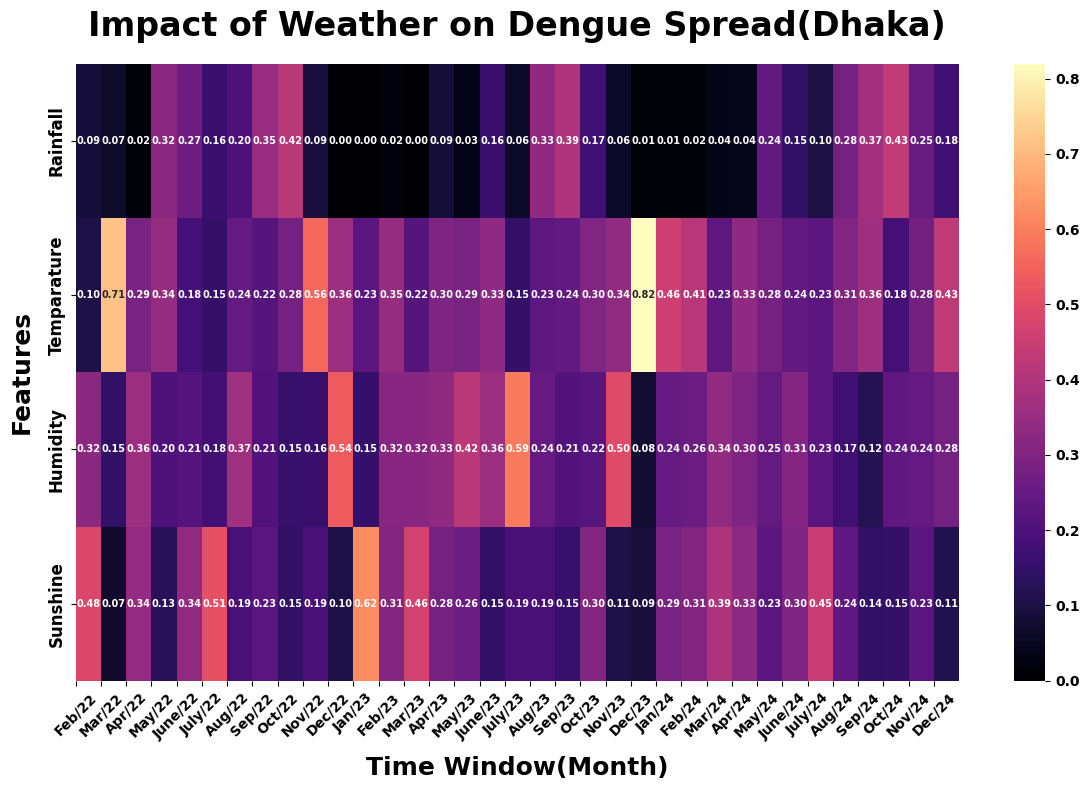

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
scaler=StandardScaler()
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler


dfy=pd.read_csv('/content/Dhaka.csv')
dfy
dfy1=dfy[['affected-Dhaka','Rainfall','Temparature','Humidity','Sunshine']]
dfy1

#ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064),(1065,1095)]

ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064)]
month = ['Feb/22', 'Mar/22', 'Apr/22', 'May/22', 'June/22', 'July/22', 'Aug/22', 'Sep/22', 'Oct/22', 'Nov/22', 'Dec/22', 'Jan/23', 'Feb/23', 'Mar/23', 'Apr/23', 'May/23', 'June/23', 'July/23', 'Aug/23', 'Sep/23', 'Oct/23', 'Nov/23', 'Dec/23','Jan/24', 'Feb/24', 'Mar/24', 'Apr/24', 'May/24', 'June/24', 'July/24', 'Aug/24', 'Sep/24', 'Oct/24', 'Nov/24', 'Dec/24']



dict1={}
dict2={}

indx=0
dur= len(dfy1)//36
avg = []
#for i, (start, end) in enumerate(ind):
    #dfx2 = dfx1.iloc[start:end+1]
for i in range(0, 35):
    dfy2 = dfy1.iloc[indx:indx+dur].copy()
    indx+=dur
    dfy3 = dfy1.iloc[indx:indx+dur].copy()
    #print(dfx3['effected'])
    avg.append(dfy3['affected-Dhaka'].mean())

    #print(dfx2)
    x=dfy2.iloc[:, 1:]
    y=dfy3.iloc[:,0]
    #print(x)
    #print(y)
    x_scaled = scaler.fit_transform(x)
    imp_list = []
    for seed in range(0,42):
      rf_model=RandomForestRegressor(n_estimators=200, random_state=seed)
      rf_model.fit(x_scaled,y)
      rf_importances=rf_model.feature_importances_
      imp_list.append(rf_importances)
      #print(imp_list)
    imp_list = np.array(imp_list)
    print(imp_list)
    mean_imp = np.mean(imp_list, axis=0)
    std_imp = np.std(imp_list, axis=0)

    dict1[month[i]]=mean_imp
    dict2[month[i]]=std_imp



rf_df1 = pd.DataFrame(dict1, index=x.columns)
std_df1 = pd.DataFrame(dict2, index=x.columns)

#print(avg)
print("Random Forest Feature Importances:")
print(rf_df1)
print(std_df1)

scaler = MinMaxScaler()
avg = scaler.fit_transform(np.array(avg).reshape(-1, 1))
# Print the sum of feature importances for each month
print("\nSum of Random Forest Feature Importances per month:")
print(rf_df1.sum())

plt.figure(figsize=(12, 8))
sns.heatmap(rf_df1, annot=True, cmap="magma", fmt=".2f", annot_kws={"size": 7,'fontweight':'bold'})
plt.gcf().axes[-1].yaxis.set_tick_params(labelsize=10)
for label in plt.gcf().axes[-1].get_yticklabels():
    label.set_fontweight('bold')
plt.xlabel('Time Window(Month)', fontsize=18, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Features', fontsize=18, fontweight='bold', family='Arial', labelpad=10)
plt.title('Impact of Weather on Dengue Spread(Dhaka)', fontsize=24,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')


plt.tight_layout()
plt.show()

In [ ]:
# Create Mean ± SD table
uncertainty_df1 = pd.DataFrame(index=rf_df1.index)

for col in rf_df1.columns:
    uncertainty_df1[col] = (
        rf_df1[col].map(lambda x: f"{x:.2f}") +
        " ± " +
        std_df1[col].map(lambda x: f"{x:.3f}")
    )

print(uncertainty_df1)

# Save to CSV
uncertainty_df1.to_csv("Importance(Dhaka).csv",index_label='Feature', encoding='utf-8-sig')
#df3= pd.read_csv('/content/RF_FeatureImportance_Mean_SD.csv')
#print(df3)

                   Feb/22        Mar/22        Apr/22        May/22  \
Rainfall     0.09 ± 0.007  0.07 ± 0.008  0.02 ± 0.002  0.32 ± 0.014   
Temparature  0.10 ± 0.011  0.71 ± 0.026  0.29 ± 0.010  0.34 ± 0.014   
Humidity     0.32 ± 0.017  0.15 ± 0.021  0.36 ± 0.014  0.20 ± 0.011   
Sunshine     0.48 ± 0.017  0.07 ± 0.010  0.34 ± 0.015  0.13 ± 0.009   

                  June/22       July/22        Aug/22        Sep/22  \
Rainfall     0.27 ± 0.015  0.16 ± 0.012  0.20 ± 0.012  0.35 ± 0.015   
Temparature  0.18 ± 0.011  0.15 ± 0.009  0.24 ± 0.015  0.22 ± 0.013   
Humidity     0.21 ± 0.011  0.18 ± 0.012  0.37 ± 0.017  0.21 ± 0.013   
Sunshine     0.34 ± 0.015  0.51 ± 0.015  0.19 ± 0.012  0.23 ± 0.013   

                   Oct/22        Nov/22  ...        Mar/24        Apr/24  \
Rainfall     0.42 ± 0.013  0.09 ± 0.007  ...  0.04 ± 0.004  0.04 ± 0.005   
Temparature  0.28 ± 0.012  0.56 ± 0.012  ...  0.23 ± 0.011  0.33 ± 0.015   
Humidity     0.15 ± 0.012  0.16 ± 0.011  ...  0.34 ± 0.013  

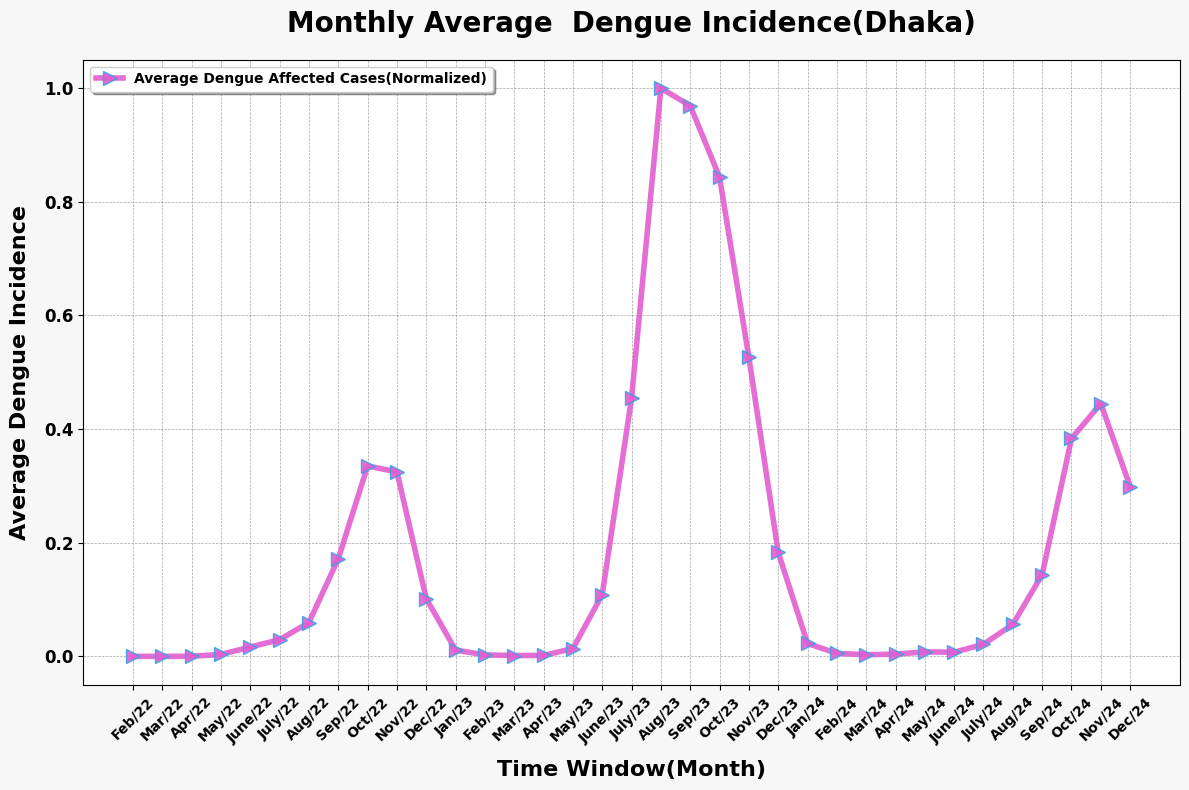

In [ ]:
plt.figure(figsize=(12,8))
#plt.plot(range(len(window)), avgpthsn, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='gray', label="avg_degree") # Changed range to len(window)
plt.plot(range(len(ind)), avg, markerfacecolor='#E15ED0',markeredgecolor='#3BA1E3', markersize=10, marker='>', linewidth=4, linestyle='-',alpha=0.9, color='#E15ED0',label="Average Dengue Affected Cases(Normalized)")
#plt.xlabel('Time Window(Month)')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Average Dengue Incidence', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Monthly Average  Dengue Incidence(Dhaka)', fontsize=20,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')

plt.legend(
    fontsize=20,
    loc='upper left',
    fancybox=True,
    shadow=True,
    prop={'weight': 'bold'}
)

# Set background color for the figure
plt.gcf().set_facecolor('#f7f7f7')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
# Adjust layout for better appearance

# Show the plot
plt.tight_layout()
#plt.savefig('oil_and_gas_net_in.png')
plt.show()


##Weather impact on dengue cases in Khulna

In [ ]:
df=df1[['Date','affected-khulna']].copy()


In [ ]:
df2=pd.read_csv('/content/d_Khulna.csv')
df2

,Date,Division,R1,R2,R3,R4,R5,R6,RH1,RH2,...,T3,T4,T5,T6,S1,S2,S3,S4,S5,S6
0,1/1/2022,Khulna,0,0,0,0,0,0,83,82,...,18.5,18.6,18.5,18.0,6.8,5.1,7.7,8.4,7.2,6.4
1,2/1/2022,Khulna,0,0,0,0,0,0,89,88,...,16.1,16.7,17.3,16.3,3.0,3.9,0.7,3.5,6.0,4.3
2,3/1/2022,Khulna,0,0,0,0,0,0,85,82,...,17.9,18.4,17.7,16.9,4.3,5.8,8.5,9.0,8.2,6.7
3,4/1/2022,Khulna,0,0,0,0,0,0,89,84,...,17.6,18.1,17.0,15.1,4.3,5.7,8.3,8.9,7.8,3.6
4,5/1/2022,Khulna,0,0,0,0,0,0,88,83,...,17.5,18.3,17.1,14.6,4.6,3.8,9.0,8.8,7.6,3.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,27-12-24,Khulna,0,0,0,0,0,0,80,78,...,20.2,20.6,20.0,18.8,7.9,8.2,6.7,7.2,9.2,6.9
1092,28-12-24,Khulna,0,0,0,0,0,0,79,75,...,20.5,20.3,19.7,19.3,9.0,8.3,8.0,7.9,8.9,6.9
1093,29-12-24,Khulna,0,0,0,0,0,0,80,79,...,20.9,21.1,20.6,19.3,8.2,7.6,7.1,7.5,8.3,6.4
1094,30-12-24,Khulna,0,0,0,0,0,0,85,82,...,21.4,21.5,21.4,19.3,3.1,2.9,5.4,3.9,6.4,2.9


In [ ]:
df2.isnull().sum()


,0
Date,0
Division,0
R1,0
R2,0
R3,0
R4,0
R5,0
R6,0
RH1,0
RH2,0


In [ ]:
#df2.ffill(inplace=True)
df2 = df2.interpolate(method='linear')
df2.isnull().sum()

/tmp/ipykernel_2095/2378441509.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df2 = df2.interpolate(method='linear')


,0
Date,0
Division,0
R1,0
R2,0
R3,0
R4,0
R5,0
R6,0
RH1,0
RH2,0


#Mean weather values of all stations in Khulna

In [ ]:
df['Rainfall']=df2[['R1','R2','R3','R4','R5','R6']].mean(axis=1)
df['Humidity']=df2[['RH1','RH2','RH3','RH4','RH5','RH6']].mean(axis=1)
df['Temparature']=df2[['T1','T2','T3','T4','T5','T6']].mean(axis=1)
df['Sunshine']=df2[['S1','S2','S3','S4','S5','S6']].mean(axis=1)


df.to_csv('khulna.csv', index=False)
df

,Date,affected-khulna,Rainfall,Humidity,Temparature,Sunshine
0,1/1/2022,0.0,0.0,79.666667,17.983333,6.933333
1,2/1/2022,0.0,0.0,87.833333,16.283333,3.566667
2,3/1/2022,0.0,0.0,81.333333,17.200000,7.083333
3,4/1/2022,0.0,0.0,82.666667,16.133333,6.433333
4,5/1/2022,0.0,0.0,82.333333,16.216667,6.183333
...,...,...,...,...,...,...
1091,27-12-24,2.0,0.0,75.833333,19.500000,7.683333
1092,28-12-24,2.0,0.0,76.833333,19.516667,8.166667
1093,29-12-24,20.0,0.0,76.833333,19.966667,7.516667
1094,30-12-24,9.0,0.0,80.000000,20.350000,4.100000


#Weather impact on dengue cases in Khulna devision

Random Forest Feature Importances:
               Feb/22    Mar/22    Apr/22    May/22   June/22   July/22  \
Rainfall     0.002818  0.344894  0.000000  0.000000  0.533651  0.360718   
Temparature  0.000000  0.140533  0.000759  0.310945  0.072635  0.225377   
Humidity     0.060568  0.270045  0.497422  0.213131  0.126899  0.220926   
Sunshine     0.936614  0.244529  0.501818  0.475924  0.266815  0.192979   

               Aug/22    Sep/22    Oct/22    Nov/22  ...    Mar/24    Apr/24  \
Rainfall     0.254994  0.481281  0.204282  0.135434  ...  0.070048  0.060384   
Temparature  0.236599  0.125911  0.387795  0.542934  ...  0.205536  0.389698   
Humidity     0.185751  0.143674  0.173038  0.150696  ...  0.304623  0.389966   
Sunshine     0.322657  0.249134  0.234884  0.170937  ...  0.419793  0.159952   

               May/24   June/24   July/24    Aug/24    Sep/24    Oct/24  \
Rainfall     0.115313  0.105595  0.156283  0.521818  0.218139  0.342615   
Temparature  0.253285  0.272806  0.496

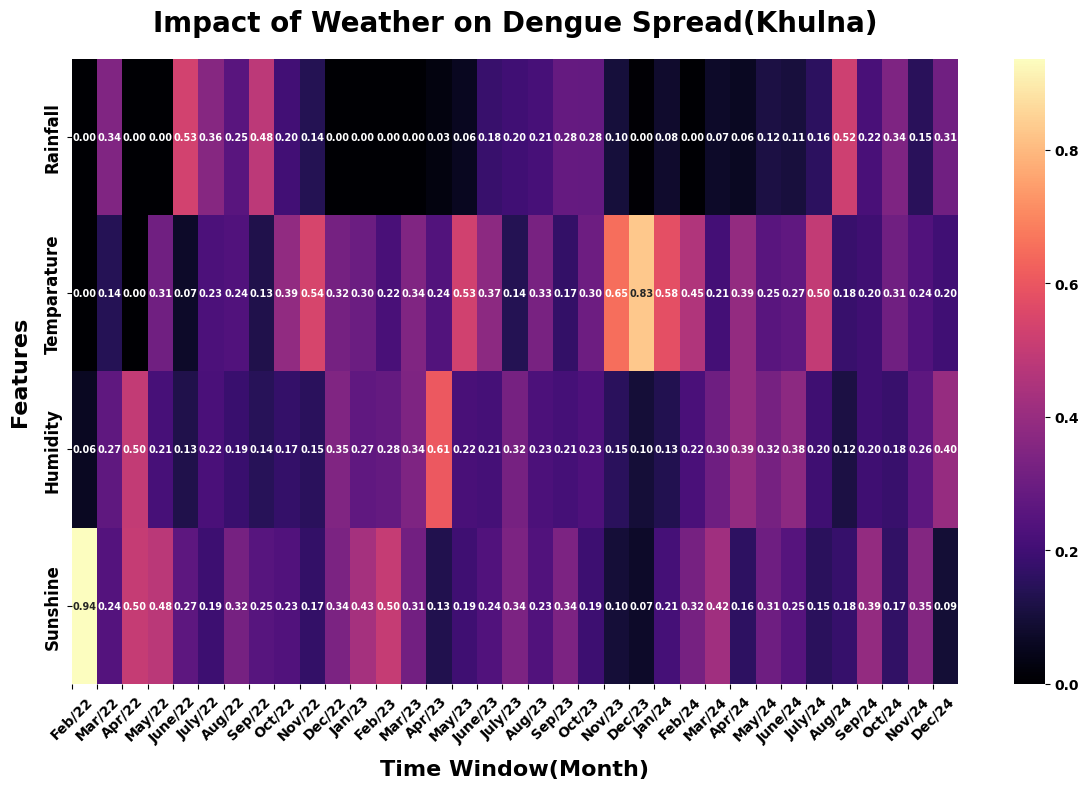

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
scaler=StandardScaler()
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
dfx=pd.read_csv('/content/khulna.csv')
dfx
dfx1=dfx[['affected-khulna','Rainfall','Temparature','Humidity','Sunshine']]
dfx1

#ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064),(1065,1095)]

ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064)]
month = ['Feb/22', 'Mar/22', 'Apr/22', 'May/22', 'June/22', 'July/22', 'Aug/22', 'Sep/22', 'Oct/22', 'Nov/22', 'Dec/22', 'Jan/23', 'Feb/23', 'Mar/23', 'Apr/23', 'May/23', 'June/23', 'July/23', 'Aug/23', 'Sep/23', 'Oct/23', 'Nov/23', 'Dec/23','Jan/24', 'Feb/24', 'Mar/24', 'Apr/24', 'May/24', 'June/24', 'July/24', 'Aug/24', 'Sep/24', 'Oct/24', 'Nov/24', 'Dec/24']



dict1={}
dict2={}

indx=0
dur= len(dfx1)//36

avg=[]
#for i, (start, end) in enumerate(ind):
    #dfx2 = dfx1.iloc[start:end+1]
for i in range(0, 35):
    dfx2 = dfx1.iloc[indx:indx+dur].copy()
    indx+=dur
    dfx3 = dfx1.iloc[indx:indx+dur].copy()
    avg.append(dfx3['affected-khulna'].mean())

    #print(dfx3['effected'])

    #print(dfx2)
    x=dfx2.iloc[:, 1:]
    y=dfx3.iloc[:,0]
    #print(x)
    #print(y)
    x_scaled = scaler.fit_transform(x)
    imp_list = []
    for seed in range(0,42):
      rf_model=RandomForestRegressor(n_estimators=200, random_state=seed)
      rf_model.fit(x_scaled,y)
      rf_importances=rf_model.feature_importances_
      imp_list.append(rf_importances)

    imp_list = np.array(imp_list)
    mean_imp = np.mean(imp_list, axis=0)
    std_imp = np.std(imp_list, axis=0)

    dict1[month[i]]=mean_imp
    dict2[month[i]]=std_imp



rf_df = pd.DataFrame(dict1, index=x.columns)
std_df = pd.DataFrame(dict2, index=x.columns)
scaler = MinMaxScaler()
avg = scaler.fit_transform(np.array(avg).reshape(-1, 1))
#print(avg)
print("Random Forest Feature Importances:")
print(rf_df)
print(std_df)

# Print the sum of feature importances for each month
print("\nSum of Random Forest Feature Importances per month:")
print(rf_df.sum())

plt.figure(figsize=(12, 8))
sns.heatmap(rf_df, annot=True, cmap="magma", fmt=".2f", annot_kws={"size": 7,'fontweight':'bold'})
plt.gcf().axes[-1].yaxis.set_tick_params(labelsize=10)
for label in plt.gcf().axes[-1].get_yticklabels():
    label.set_fontweight('bold')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Features', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Impact of Weather on Dengue Spread(Khulna)', fontsize=20,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')


plt.tight_layout()
plt.show()

#feature importances with standard deviation

In [ ]:
# Create Mean ± SD table
uncertainty_df1 = pd.DataFrame(index=rf_df.index)

for col in rf_df.columns:
    uncertainty_df1[col] = (
        rf_df[col].map(lambda x: f"{x:.2f}") +
        " ± " +
        std_df[col].map(lambda x: f"{x:.3f}")
    )

print(uncertainty_df1)

# Save to CSV
uncertainty_df1.to_csv("Importance(Khulna).csv",index_label='Feature', encoding='utf-8-sig')
#df3= pd.read_csv('/content/RF_FeatureImportance_Mean_SD.csv')
#print(df3)

                   Feb/22        Mar/22        Apr/22        May/22  \
Rainfall     0.00 ± 0.004  0.34 ± 0.030  0.00 ± 0.000  0.00 ± 0.000   
Temparature  0.00 ± 0.000  0.14 ± 0.017  0.00 ± 0.002  0.31 ± 0.038   
Humidity     0.06 ± 0.025  0.27 ± 0.021  0.50 ± 0.038  0.21 ± 0.028   
Sunshine     0.94 ± 0.028  0.24 ± 0.019  0.50 ± 0.038  0.48 ± 0.044   

                  June/22       July/22        Aug/22        Sep/22  \
Rainfall     0.53 ± 0.017  0.36 ± 0.016  0.25 ± 0.013  0.48 ± 0.015   
Temparature  0.07 ± 0.010  0.23 ± 0.013  0.24 ± 0.013  0.13 ± 0.007   
Humidity     0.13 ± 0.016  0.22 ± 0.012  0.19 ± 0.010  0.14 ± 0.011   
Sunshine     0.27 ± 0.012  0.19 ± 0.014  0.32 ± 0.016  0.25 ± 0.013   

                   Oct/22        Nov/22  ...        Mar/24        Apr/24  \
Rainfall     0.20 ± 0.011  0.14 ± 0.007  ...  0.07 ± 0.008  0.06 ± 0.009   
Temparature  0.39 ± 0.015  0.54 ± 0.011  ...  0.21 ± 0.013  0.39 ± 0.016   
Humidity     0.17 ± 0.013  0.15 ± 0.007  ...  0.30 ± 0.015  

#Normalized Curve of average dengue cases in Khulna

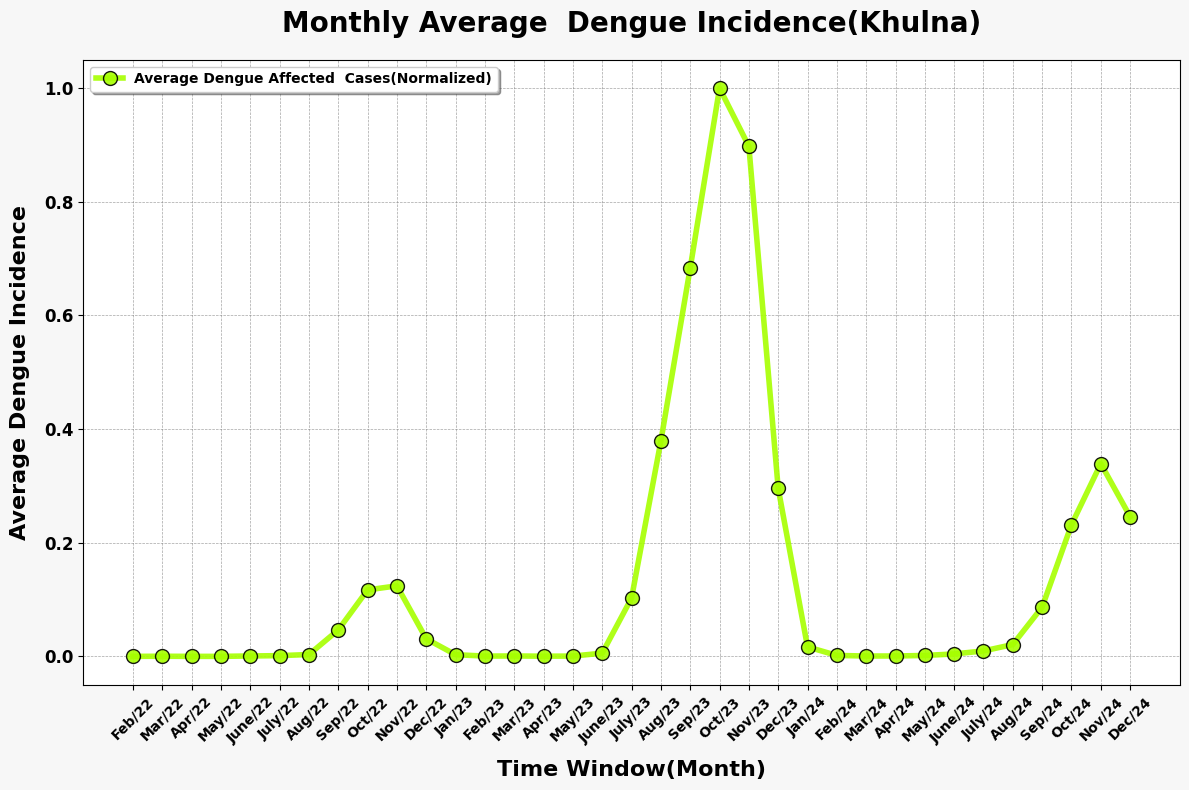

In [ ]:
plt.figure(figsize=(12,8))
#plt.plot(range(len(window)), avgpthsn, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='gray', label="avg_degree") # Changed range to len(window)
plt.plot(range(len(ind)), avg, markerfacecolor='#a6ff00',markeredgecolor='black', markersize=10, marker='o', linewidth=4, linestyle='-',alpha=0.9, color='#a6ff00',label="Average Dengue Affected  Cases(Normalized)")
#plt.xlabel('Time Window(Month)')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Average Dengue Incidence', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Monthly Average  Dengue Incidence(Khulna)', fontsize=20,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')

plt.legend(
    fontsize=18,
    loc='upper left',
    fancybox=True,
    shadow=True,
    prop={'weight': 'bold'}
)

# Set background color for the figure
plt.gcf().set_facecolor('#f7f7f7')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
# Adjust layout for better appearance

# Show the plot
plt.tight_layout()
#plt.savefig('oil_and_gas_net_in.png')
plt.show()

#Feature ranking analysis for Chittagong Division

In [8]:

dfc= pd.read_csv('/content/d_Chittagong.csv')
dfc.isnull().sum()


,0
Date,0
R_Chandpur,0
R_Chittagong,0
R_Comilla,0
R_Coxsbazar,0
R_Feni,0
R_Hatiya,0
R_Kutubdia,0
R_M.Court,0
R_Rangamati,0


In [9]:
dfc['S_Hatiya']=dfc['S_Hatiya'].interpolate(method='linear')
dfc.isnull().sum()

,0
Date,0
R_Chandpur,0
R_Chittagong,0
R_Comilla,0
R_Coxsbazar,0
R_Feni,0
R_Hatiya,0
R_Kutubdia,0
R_M.Court,0
R_Rangamati,0


In [10]:
dfc1= df1[['Date','affected-chittagong']]
dfc1


,Date,affected-chittagong
0,1/1/2022,1.0
1,2/1/2022,0.0
2,3/1/2022,25.0
3,4/1/2022,0.0
4,5/1/2022,2.0
...,...,...
1091,27-12-24,12.0
1092,28-12-24,7.0
1093,29-12-24,27.0
1094,30-12-24,11.0


In [11]:
dfc1['Rainfall']=dfc[['R_Chandpur','R_Chittagong','R_Comilla','R_Coxsbazar','R_Feni','R_Hatiya','R_Kutubdia','R_M.Court','R_Rangamati','R_Sandwip','R_Ambagan','R_Sitakunda']].mean(axis=1)
dfc1['Temparature']= dfc[['Tavg-Chandpur','Tavg-Chittagong','Tavg-Comilla','Tavg-Coxsbazar','Tavg-Feni','Tavg-Hatiya','Tavg-Kutubdia','Tavg-M.Court','Tavg-Rangamati','Tavg-Sandwip','Tavg-Ambagan','Tavg-Sitakunda']].mean(axis=1)
dfc1['Sunshine'] = dfc[['S_Chandpur','S_Chittagong','S_Comilla','S_Coxsbazar','S_Feni','S_Hatiya','S_Kutubdia','S_M.Court','S_Rangamati','S_Sandwip','S_Ambagan','S_Sitakunda']].mean(axis=1)
dfc1.loc[:974, 'Humidity'] = dfc.loc[:974, ['RH_Chandpur','RH_Chittagong','RH_Comilla','RH_Coxsbazar','RH_Feni','RH_Hatiya','RH_Kutubdia','RH_M.Court','RH_Rangamati','RH_Sandwip','RH_Ambagan','RH_Sitakunda']].mean(axis=1)
dfc1.loc[975:, 'Humidity'] = dfc.loc[975:, ['RH_Chandpur','RH_Chittagong','RH_Comilla','RH_Coxsbazar','RH_Feni','RH_Kutubdia','RH_M.Court','RH_Rangamati','RH_Sandwip','RH_Ambagan','RH_Sitakunda']].mean(axis=1)

dfc1.to_csv('Chittagong.csv', index=False)
dfc1

/tmp/ipykernel_741/3513359315.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfc1['Rainfall']=dfc[['R_Chandpur','R_Chittagong','R_Comilla','R_Coxsbazar','R_Feni','R_Hatiya','R_Kutubdia','R_M.Court','R_Rangamati','R_Sandwip','R_Ambagan','R_Sitakunda']].mean(axis=1)
/tmp/ipykernel_741/3513359315.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfc1['Temparature']= dfc[['Tavg-Chandpur','Tavg-Chittagong','Tavg-Comilla','Tavg-Coxsbazar','Tavg-Feni','Tavg-Hatiya','Tavg-Kutubdia','Tavg-M.Court','Tavg-Ranga

,Date,affected-chittagong,Rainfall,Temparature,Sunshine,Humidity
0,1/1/2022,1.0,0.0,19.983333,8.483333,72.166667
1,2/1/2022,0.0,0.0,19.366667,7.475000,78.416667
2,3/1/2022,25.0,0.0,19.075000,6.991667,82.250000
3,4/1/2022,0.0,0.0,19.341667,7.783333,79.333333
4,5/1/2022,2.0,0.0,18.983333,7.116667,82.166667
...,...,...,...,...,...,...
1091,27-12-24,12.0,0.0,21.225000,6.725000,70.727273
1092,28-12-24,7.0,0.0,20.808333,6.891667,75.636364
1093,29-12-24,27.0,0.0,21.000000,5.675000,76.272727
1094,30-12-24,11.0,0.0,21.300000,6.075000,74.818182


Random Forest Feature Importances:
               Feb/22    Mar/22    Apr/22    May/22   June/22   July/22  \
Rainfall     0.231584  0.007212  0.000524  0.622847  0.323924  0.185626   
Temparature  0.191563  0.351284  0.461443  0.080001  0.193551  0.176461   
Humidity     0.421174  0.260560  0.237511  0.215272  0.196739  0.452509   
Sunshine     0.155679  0.380945  0.300522  0.081881  0.285786  0.185405   

               Aug/22    Sep/22    Oct/22    Nov/22  ...    Mar/24    Apr/24  \
Rainfall     0.111254  0.219869  0.384472  0.236092  ...  0.096550  0.007630   
Temparature  0.486757  0.372515  0.342927  0.345929  ...  0.355765  0.562572   
Humidity     0.169604  0.140727  0.161801  0.160517  ...  0.207663  0.139486   
Sunshine     0.232385  0.266889  0.110800  0.257463  ...  0.340021  0.290312   

               May/24   June/24   July/24    Aug/24    Sep/24    Oct/24  \
Rainfall     0.161386  0.159943  0.115079  0.425655  0.235511  0.353045   
Temparature  0.283568  0.209592  0.154

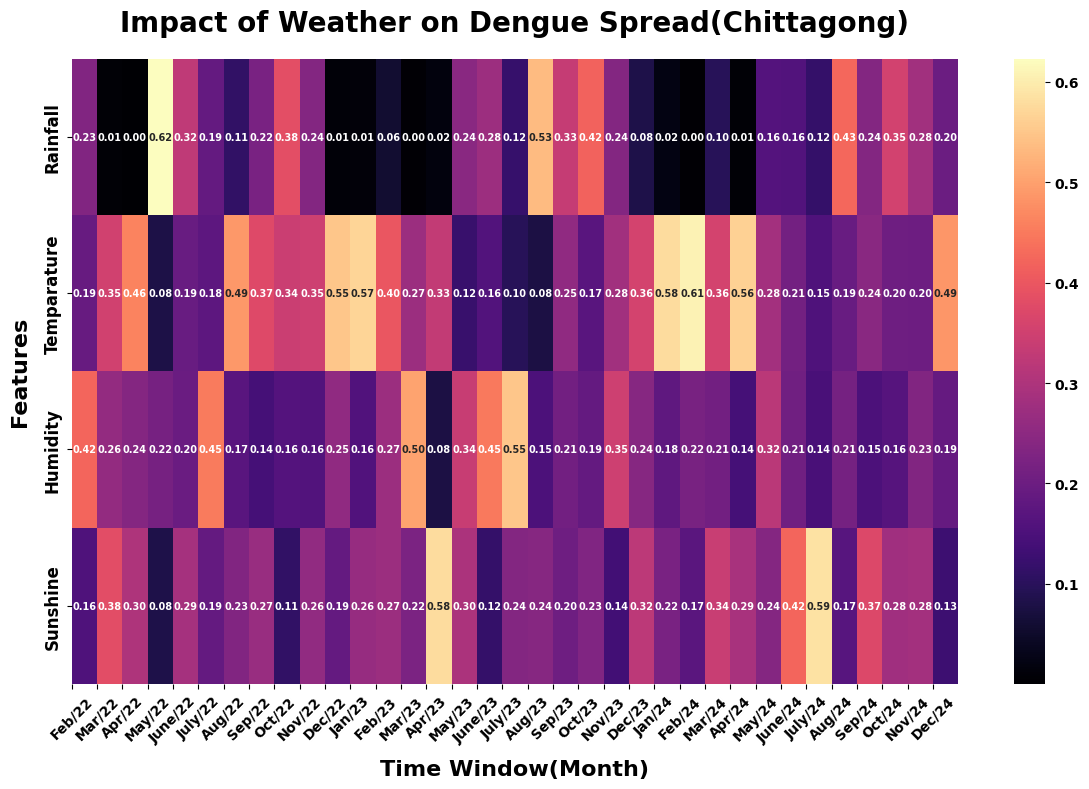

In [12]:
dfz=pd.read_csv('/content/Chittagong.csv')
dfz
dfz1=dfz[['affected-chittagong','Rainfall','Temparature','Humidity','Sunshine']]
dfz1

#ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064),(1065,1095)]

ind= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064)]
month = ['Feb/22', 'Mar/22', 'Apr/22', 'May/22', 'June/22', 'July/22', 'Aug/22', 'Sep/22', 'Oct/22', 'Nov/22', 'Dec/22', 'Jan/23', 'Feb/23', 'Mar/23', 'Apr/23', 'May/23', 'June/23', 'July/23', 'Aug/23', 'Sep/23', 'Oct/23', 'Nov/23', 'Dec/23','Jan/24', 'Feb/24', 'Mar/24', 'Apr/24', 'May/24', 'June/24', 'July/24', 'Aug/24', 'Sep/24', 'Oct/24', 'Nov/24', 'Dec/24']



dict1={}
dict2={}

indx=0
dur= len(dfz1)//36
avg = []
#for i, (start, end) in enumerate(ind):
    #dfx2 = dfx1.iloc[start:end+1]
for i in range(0, 35):
    dfz2 = dfz1.iloc[indx:indx+dur].copy()
    indx+=dur
    dfz3 = dfz1.iloc[indx:indx+dur].copy()
    #print(dfx3['effected'])
    avg.append(dfz3['affected-chittagong'].mean())
    #print(dfx2)
    x=dfz2.iloc[:, 1:]
    y=dfz3.iloc[:,0]
    #print(x)
    #print(y)
    x_scaled = scaler.fit_transform(x)
    imp_list = []
    for seed in range(0,42):
      rf_model=RandomForestRegressor(n_estimators=200, random_state=seed)
      rf_model.fit(x_scaled,y)
      rf_importances=rf_model.feature_importances_
      imp_list.append(rf_importances)

    imp_list = np.array(imp_list)
    mean_imp = np.mean(imp_list, axis=0)
    std_imp = np.std(imp_list, axis=0)

    dict1[month[i]]=mean_imp
    dict2[month[i]]=std_imp



rf_df2 = pd.DataFrame(dict1, index=x.columns)
std_df2 = pd.DataFrame(dict2, index=x.columns)

#print(avg)
print("Random Forest Feature Importances:")
print(rf_df2)
print(std_df2)

scaler = MinMaxScaler()
avg = scaler.fit_transform(np.array(avg).reshape(-1, 1))
# Print the sum of feature importances for each month
print("\nSum of Random Forest Feature Importances per month:")
print(rf_df2.sum())

plt.figure(figsize=(12, 8))
sns.heatmap(rf_df2, annot=True, cmap="magma", fmt=".2f", annot_kws={"size": 7,'fontweight':'bold'})
plt.gcf().axes[-1].yaxis.set_tick_params(labelsize=10)
for label in plt.gcf().axes[-1].get_yticklabels():
    label.set_fontweight('bold')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Features', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Impact of Weather on Dengue Spread(Chittagong)', fontsize=20,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')


plt.tight_layout()
plt.show()

In [13]:
# Create Mean ± SD table
uncertainty_df2 = pd.DataFrame(index=rf_df2.index)

for col in rf_df2.columns:
    uncertainty_df2[col] = (
        rf_df2[col].map(lambda x: f"{x:.2f}") +
        " ± " +
        std_df2[col].map(lambda x: f"{x:.3f}")
    )

print(uncertainty_df2)

# Save to CSV
uncertainty_df2.to_csv("Importance(Chitagong).csv",index_label="Feature", encoding='utf-8-sig')
#df3= pd.read_csv('/content/RF_FeatureImportance_Mean_SD.csv')
#print(df3)

                   Feb/22        Mar/22        Apr/22        May/22  \
Rainfall     0.23 ± 0.017  0.01 ± 0.004  0.00 ± 0.001  0.62 ± 0.038   
Temparature  0.19 ± 0.021  0.35 ± 0.024  0.46 ± 0.025  0.08 ± 0.018   
Humidity     0.42 ± 0.024  0.26 ± 0.018  0.24 ± 0.020  0.22 ± 0.035   
Sunshine     0.16 ± 0.015  0.38 ± 0.022  0.30 ± 0.023  0.08 ± 0.019   

                  June/22       July/22        Aug/22        Sep/22  \
Rainfall     0.32 ± 0.022  0.19 ± 0.009  0.11 ± 0.009  0.22 ± 0.013   
Temparature  0.19 ± 0.015  0.18 ± 0.012  0.49 ± 0.015  0.37 ± 0.014   
Humidity     0.20 ± 0.022  0.45 ± 0.016  0.17 ± 0.011  0.14 ± 0.009   
Sunshine     0.29 ± 0.022  0.19 ± 0.013  0.23 ± 0.014  0.27 ± 0.009   

                   Oct/22        Nov/22  ...        Mar/24        Apr/24  \
Rainfall     0.38 ± 0.015  0.24 ± 0.015  ...  0.10 ± 0.010  0.01 ± 0.001   
Temparature  0.34 ± 0.013  0.35 ± 0.016  ...  0.36 ± 0.012  0.56 ± 0.012   
Humidity     0.16 ± 0.011  0.16 ± 0.010  ...  0.21 ± 0.010  

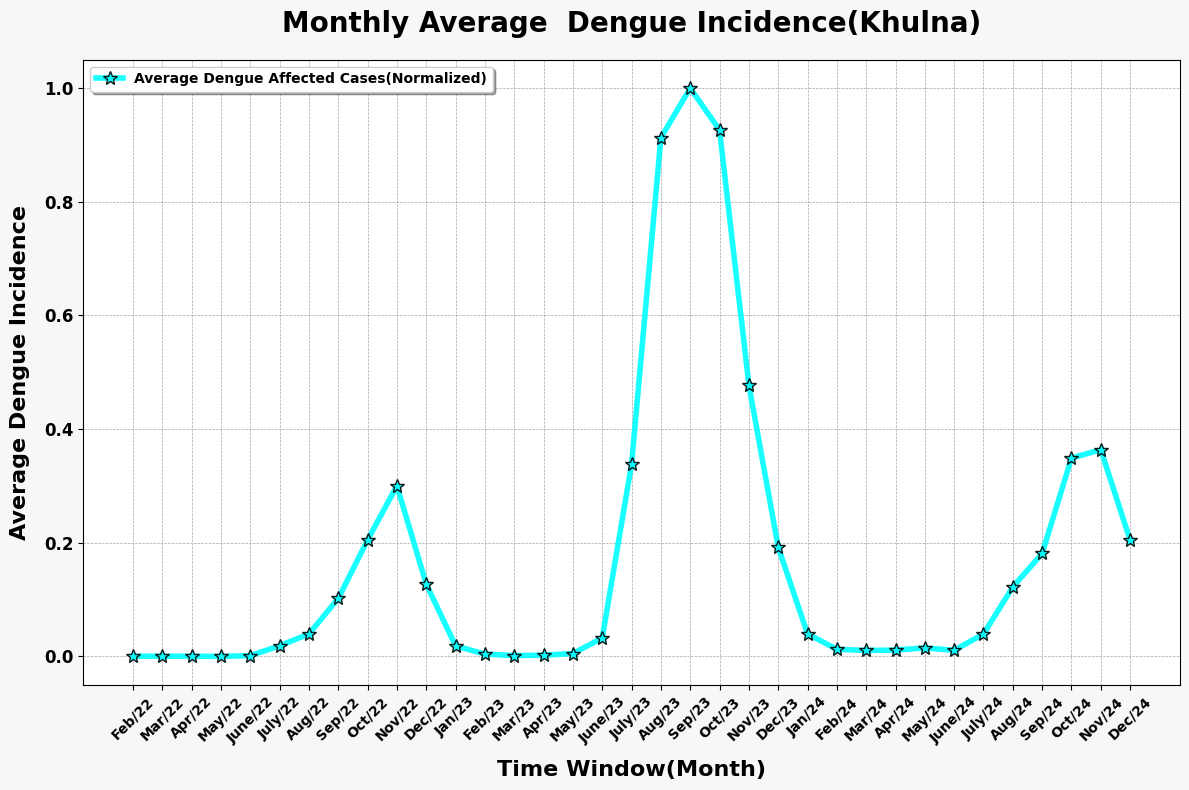

In [18]:
plt.figure(figsize=(12,8))
#plt.plot(range(len(window)), avgpthsn, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='gray', label="avg_degree") # Changed range to len(window)
#plt.plot(range(len(ind)), avg, markerfacecolor='#a6ff00',markeredgecolor='black', markersize=10, marker='o', linewidth=4, linestyle='-',alpha=0.9, color='#a6ff00',label="Average Dengue Affected Cases(Normalized)")
plt.plot(range(len(ind)), avg, markerfacecolor='Aqua',markeredgecolor='black', markersize=10, marker='*', linewidth=4, linestyle='-',alpha=0.9, color='Aqua',label="Average Dengue Affected Cases(Normalized)")

#plt.xlabel('Time Window(Month)')
plt.xlabel('Time Window(Month)', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
#plt.ylabel('Average values')
plt.ylabel('Average Dengue Incidence', fontsize=16, fontweight='bold', family='Arial', labelpad=10)
plt.title('Monthly Average  Dengue Incidence(Khulna)', fontsize=20,
    fontweight='bold',
    family='Arial',
    pad=20)
#plt.xticks(rotation=45, ha='right')
plt.xticks(
    ticks=np.arange(len(month)),
    labels=month,
    rotation=45,
    fontsize=10,
    fontweight='bold',
    family='Arial'
)
plt.yticks(fontsize=12, fontweight='bold', family='Arial')

plt.legend(
    fontsize=12,
    loc='upper left',
    fancybox=True,
    shadow=True,
    prop={'weight': 'bold'}
)

# Set background color for the figure
plt.gcf().set_facecolor('#f7f7f7')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
# Adjust layout for better appearance

# Show the plot
plt.tight_layout()
#plt.savefig('oil_and_gas_net_in.png')
plt.show()